In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

## Zadanie 1 – Schematy iteracyjne dla x^2 - 3x + 2 = 0, pierwiastek alpha=2

In [5]:
alpha = np.float64(2.0)

phi1 = lambda x: (x**2 + 2) / 3
phi2 = lambda x: np.sqrt(3*x - 2) if 3*x - 2 >= 0 else float('nan')
phi3 = lambda x: 3 - 2/x
phi4 = lambda x: (x**2 - 2) / (2*x - 3)

dphi1 = lambda x: 2*x / 3
dphi2 = lambda x: 3 / (2*np.sqrt(3*x - 2))
dphi3 = lambda x: 2 / x**2
dphi4 = lambda x: (2*x*(2*x-3) - 2*(x**2-2)) / (2*x-3)**2

phis = [phi1, phi2, phi3, phi4]
dphis = [dphi1, dphi2, dphi3, dphi4]
names = ['phi1=(x^2+2)/3', 'phi2=sqrt(3x-2)', 'phi3=3-2/x', 'phi4=(x^2-2)/(2x-3)']

print(f"{'Schemat':<22} {'phi(2)':>12} {'Zbiezny':>10}")
print("-" * 48)
for name, dphi in zip(names, dphis):
    val = abs(dphi(alpha))
    conv = 'TAK' if val < 1 else 'NIE'
    print(f"{name:<22} {val:>12.6f} {conv:>10}")

Schemat                      phi(2)    Zbiezny
------------------------------------------------
phi1=(x^2+2)/3             1.333333        NIE
phi2=sqrt(3x-2)            0.750000        TAK
phi3=3-2/x                 0.500000        TAK
phi4=(x^2-2)/(2x-3)        0.000000        TAK


In [6]:
def iterate(phi, x0, n=10):
    xs = [np.float64(x0)]
    for _ in range(n):
        try:
            xn = phi(xs[-1])
            if np.isnan(xn) or np.isinf(xn) or abs(xn) > 1e15:
                xs.append(np.nan)
                break
            xs.append(np.float64(xn))
        except:
            xs.append(np.nan)
            break
    return xs

x0 = np.float64(2.5)
results = {}

for name, phi in zip(names, phis):
    xs = iterate(phi, x0)
    results[name] = xs
    print(f"\n{name}:")
    for i, x in enumerate(xs):
        err = abs(x - alpha) if not np.isnan(x) else np.nan
        print(f"  k={i}: x={x:.10f}, err={err:.2e}")


phi1=(x^2+2)/3:
  k=0: x=2.5000000000, err=5.00e-01
  k=1: x=2.7500000000, err=7.50e-01
  k=2: x=3.1875000000, err=1.19e+00
  k=3: x=4.0533854167, err=2.05e+00
  k=4: x=6.1433111120, err=4.14e+00
  k=5: x=13.2467571397, err=1.12e+01
  k=6: x=59.1588582391, err=5.72e+01
  k=7: x=1167.2568360527, err=1.17e+03
  k=8: x=454163.5071039423, err=4.54e+05
  k=9: x=68754830395.6508789062, err=6.88e+10
  k=10: x=nan, err=nan

phi2=sqrt(3x-2):
  k=0: x=2.5000000000, err=5.00e-01
  k=1: x=2.3452078799, err=3.45e-01
  k=2: x=2.2440195275, err=2.44e-01
  k=3: x=2.1753295342, err=1.75e-01
  k=4: x=2.1274370972, err=1.27e-01
  k=5: x=2.0933970698, err=9.34e-02
  k=6: x=2.0688622983, err=6.89e-02
  k=7: x=2.0509965614, err=5.10e-02
  k=8: x=2.0378885358, err=3.79e-02
  k=9: x=2.0282173472, err=2.82e-02
  k=10: x=2.0210522115, err=2.11e-02

phi3=3-2/x:
  k=0: x=2.5000000000, err=5.00e-01
  k=1: x=2.2000000000, err=2.00e-01
  k=2: x=2.0909090909, err=9.09e-02
  k=3: x=2.0434782609, err=4.35e-02
  k=4: x

In [7]:
print("Empiryczny rzad zbieznosci r = ln(eps_k/eps_{k+1}) / ln(eps_{k-1}/eps_k):")
for name, xs in results.items():
    errs = [abs(x - alpha) for x in xs if not np.isnan(x) and abs(x - alpha) > 1e-15]
    if len(errs) < 3:
        print(f"  {name}: brak zbieznosci lub za malo iteracji")
        continue
    rs = []
    for i in range(1, len(errs)-1):
        num = np.log(errs[i] / errs[i+1]) if errs[i+1] > 0 else np.nan
        den = np.log(errs[i-1] / errs[i]) if errs[i] > 0 else np.nan
        if den and den != 0:
            rs.append(num / den)
    valid_rs = [r for r in rs if not np.isnan(r) and not np.isinf(r)]
    if valid_rs:
        print(f"  {name}: r ~ {np.mean(valid_rs[-3:]):.3f}")
    else:
        print(f"  {name}: nie mozna wyznaczyc")

Empiryczny rzad zbieznosci r = ln(eps_k/eps_{k+1}) / ln(eps_{k-1}/eps_k):
  phi1=(x^2+2)/3: r ~ 1.944
  phi2=sqrt(3x-2): r ~ 0.992
  phi3=3-2/x: r ~ 0.999
  phi4=(x^2-2)/(2x-3): r ~ 1.856


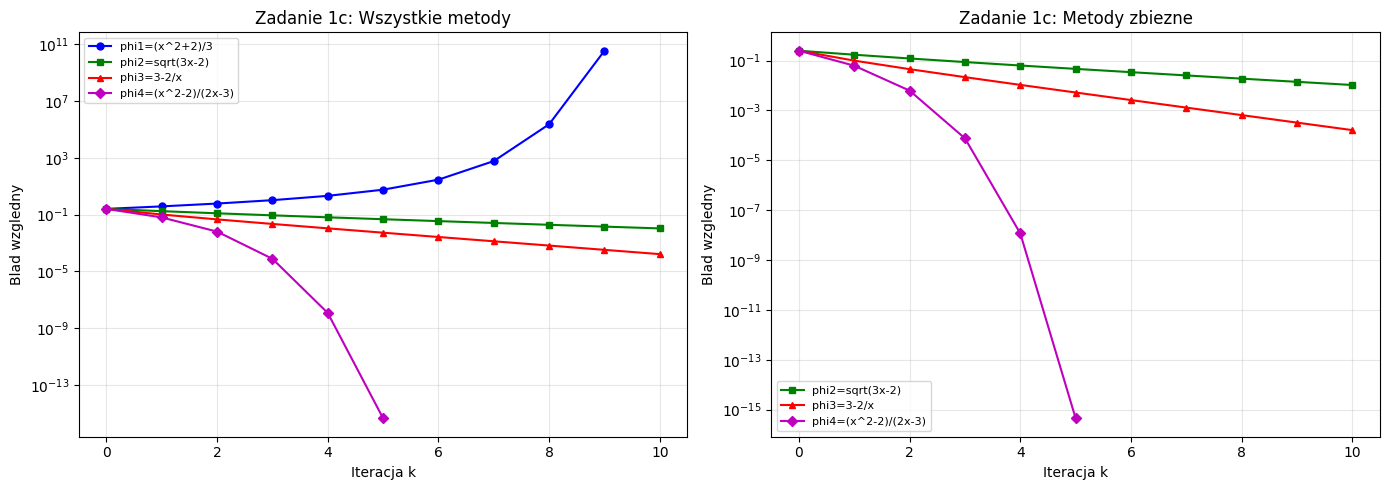

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['b', 'g', 'r', 'm']
markers = ['o', 's', '^', 'D']

for ax_idx, ax in enumerate(axes):
    for (name, xs), color, marker in zip(results.items(), colors, markers):
        errs = [abs(x - alpha)/abs(alpha) if not np.isnan(x) and abs(alpha) > 0 else np.nan for x in xs]
        valid = [(i, e) for i, e in enumerate(errs) if not np.isnan(e) and e > 0]
        if ax_idx == 1 and name in ['phi1=(x^2+2)/3']:
            continue
        if valid:
            ks, es = zip(*valid)
            ax.semilogy(ks, es, f'{color}-{marker}', markersize=5, label=name)
    ax.set_xlabel('Iteracja k')
    ax.set_ylabel('Blad wzgledny')
    title = 'Zadanie 1c: Wszystkie metody' if ax_idx == 0 else 'Zadanie 1c: Metody zbiezne'
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

## Zadanie 2 – Metoda Newtona – przypadki problematyczne

In [9]:
cases = [
    ('(a) x^3 - 5x,  x0=1',  lambda x: x**3 - 5*x,  lambda x: 3*x**2 - 5,  1.0,  'cykl: f\'(x0)=3-5=-2, Newton skacze miedzy wartosciami'),
    ('(b) x^3-3x+1,  x0=1',  lambda x: x**3 - 3*x + 1, lambda x: 3*x**2 - 3, 1.0, 'f\'(x0)=0, dzielenie przez zero'),
    ('(c) 2-x^5,     x0=0.01',lambda x: 2 - x**5,   lambda x: -5*x**4,  0.01, 'f\'(0.01) bardzo male, Newton daleko odskakuje'),
    ('(d) x^4-4.29x^2-5.29, x0=0.8', lambda x: x**4 - 4.29*x**2 - 5.29, lambda x: 4*x**3 - 8.58*x, 0.8, 'brak zbieznosci z tego punktu startowego'),
]

for label, f, fp, x0, why in cases:
    print(f"\n{label}")
    print(f"  Dlaczego zawodzi: {why}")
    try:
        root = optimize.newton(f, x0, fprime=fp, maxiter=5)
        print(f"  Newton (5 iter): {root:.6f}")
    except Exception as e:
        print(f"  Newton blad: {e}")

    try:
        root2 = optimize.brentq(f, -10, 10)
        print(f"  brentq [-10,10]: {root2:.6f}")
    except:
        for bracket in [(-5,-0.1),(0.1,5),(1,3),(-3,-1)]:
            try:
                root2 = optimize.brentq(f, bracket[0], bracket[1])
                print(f"  brentq {bracket}: {root2:.6f}")
                break
            except:
                pass


(a) x^3 - 5x,  x0=1
  Dlaczego zawodzi: cykl: f'(x0)=3-5=-2, Newton skacze miedzy wartosciami
  Newton blad: Failed to converge after 5 iterations, value is -1.0.
  brentq [-10,10]: 0.000000

(b) x^3-3x+1,  x0=1
  Dlaczego zawodzi: f'(x0)=0, dzielenie przez zero
  Newton blad: Derivative was zero. Failed to converge after 1 iterations, value is 1.0.
  brentq [-10,10]: -1.879385

(c) 2-x^5,     x0=0.01
  Dlaczego zawodzi: f'(0.01) bardzo male, Newton daleko odskakuje
  Newton blad: Failed to converge after 5 iterations, value is 16384000.0032768.
  brentq [-10,10]: 1.148698

(d) x^4-4.29x^2-5.29, x0=0.8
  Dlaczego zawodzi: brak zbieznosci z tego punktu startowego
  Newton blad: Failed to converge after 5 iterations, value is -0.7875314065411356.
  brentq (-5, -0.1): -2.300000


In [10]:
print("Naprawione wywolania newton:")

f_a  = lambda x: x**3 - 5*x
fp_a = lambda x: 3*x**2 - 5
root_a = optimize.newton(f_a, 2.5, fprime=fp_a)
print(f"(a) x0=2.5 -> root = {root_a:.8f}  (sqrt(5)={np.sqrt(5):.8f})")

f_b  = lambda x: x**3 - 3*x + 1
fp_b = lambda x: 3*x**2 - 3
root_b = optimize.newton(f_b, 1.5, fprime=fp_b)
print(f"(b) x0=1.5 -> root = {root_b:.8f}")

f_c  = lambda x: 2 - x**5
fp_c = lambda x: -5*x**4
root_c = optimize.newton(f_c, 1.0, fprime=fp_c)
print(f"(c) x0=1.0 -> root = {root_c:.8f}  (2^(1/5)={2**(1/5):.8f})")

f_d  = lambda x: x**4 - 4.29*x**2 - 5.29
fp_d = lambda x: 4*x**3 - 8.58*x
root_d = optimize.newton(f_d, 2.3, fprime=fp_d)
print(f"(d) x0=2.3 -> root = {root_d:.8f}")

Naprawione wywolania newton:
(a) x0=2.5 -> root = 2.23606798  (sqrt(5)=2.23606798)
(b) x0=1.5 -> root = 1.53208889
(c) x0=1.0 -> root = 1.14869835  (2^(1/5)=1.14869835)
(d) x0=2.3 -> root = 2.30000000


## Zadanie 3 – Schematy Newtona bez dzielenia

In [11]:
print("=== (a) x = 1/c ===")
print("f(x) = 1/x - c = 0")
print("f'(x) = -1/x^2")
print("Newton: x_{k+1} = x_k - f(x_k)/f'(x_k) = x_k - (1/x_k - c)/(-1/x_k^2)")
print("      = x_k + x_k^2*(1/x_k - c) = x_k + x_k - c*x_k^2 = 2*x_k - c*x_k^2")
print("Schemat: x_{k+1} = x_k*(2 - c*x_k)  [tylko dodawanie i mnozenie]")
print()

c_val = np.float64(3.0)
x = np.float64(0.3)
true_val = np.float64(1.0) / c_val
print(f"c={c_val}, 1/c={true_val:.10f}")
for k in range(8):
    x = x * (np.float64(2.0) - c_val * x)
    print(f"  k={k+1}: x={x:.10f}, err={abs(x-true_val):.2e}")

=== (a) x = 1/c ===
f(x) = 1/x - c = 0
f'(x) = -1/x^2
Newton: x_{k+1} = x_k - f(x_k)/f'(x_k) = x_k - (1/x_k - c)/(-1/x_k^2)
      = x_k + x_k^2*(1/x_k - c) = x_k + x_k - c*x_k^2 = 2*x_k - c*x_k^2
Schemat: x_{k+1} = x_k*(2 - c*x_k)  [tylko dodawanie i mnozenie]

c=3.0, 1/c=0.3333333333
  k=1: x=0.3300000000, err=3.33e-03
  k=2: x=0.3333000000, err=3.33e-05
  k=3: x=0.3333333300, err=3.33e-09
  k=4: x=0.3333333333, err=5.55e-17
  k=5: x=0.3333333333, err=0.00e+00
  k=6: x=0.3333333333, err=0.00e+00
  k=7: x=0.3333333333, err=0.00e+00
  k=8: x=0.3333333333, err=0.00e+00


In [12]:
print("=== (b) x = 1/sqrt(c) ===")
print("f(x) = 1/x^2 - c = 0")
print("f'(x) = -2/x^3")
print("Newton: x_{k+1} = x_k*(3 - c*x_k^2)/2  [dodawanie, mnozenie, dzielenie przez 2]")
print()

c_val = np.float64(4.0)
x = np.float64(0.45)
true_val = np.float64(1.0) / np.sqrt(c_val)
print(f"c={c_val}, 1/sqrt(c)={true_val:.10f}")
for k in range(8):
    x = x * (np.float64(3.0) - c_val * x**2) / np.float64(2.0)
    print(f"  k={k+1}: x={x:.10f}, err={abs(x-true_val):.2e}")

print()
print("=== (c) Schemat Herona x = sqrt(c) ===")
print("f(x) = x^2 - c = 0")
print("f'(x) = 2x")
print("Newton: x_{k+1} = (x_k + c/x_k) / 2  [Heron]")
print("Wada: wymaga dzielenia przez x_k (nie tylko przez 2)")
print()

c_val = np.float64(2.0)
x = np.float64(1.5)
true_val = np.sqrt(c_val)
print(f"c={c_val}, sqrt(c)={true_val:.10f}")
for k in range(8):
    x = (x + c_val / x) / np.float64(2.0)
    print(f"  k={k+1}: x={x:.10f}, err={abs(x-true_val):.2e}")

print()
print("=== (d) sqrt(c) = 1 / (1/sqrt(c)) – bez wad Herona ===")
print("Uzyj schematu z (b) aby obliczyc y = 1/sqrt(c), potem sqrt(c) = c * y")
print("Schemat (b): y_{k+1} = y_k*(3 - c*y_k^2)/2, potem sqrt(c) = c * y")
print()

c_val = np.float64(2.0)
y = np.float64(0.68)
true_val = np.sqrt(c_val)
print(f"c={c_val}, sqrt(c)={true_val:.10f}")
for k in range(8):
    y = y * (np.float64(3.0) - c_val * y**2) / np.float64(2.0)
    sqrt_c = c_val * y
    print(f"  k={k+1}: 1/sqrt(c)={y:.10f}, sqrt(c)={sqrt_c:.10f}, err={abs(sqrt_c-true_val):.2e}")

=== (b) x = 1/sqrt(c) ===
f(x) = 1/x^2 - c = 0
f'(x) = -2/x^3
Newton: x_{k+1} = x_k*(3 - c*x_k^2)/2  [dodawanie, mnozenie, dzielenie przez 2]

c=4.0, 1/sqrt(c)=0.5000000000
  k=1: x=0.4927500000, err=7.25e-03
  k=2: x=0.4998430747, err=1.57e-04
  k=3: x=0.4999999261, err=7.39e-08
  k=4: x=0.5000000000, err=1.64e-14
  k=5: x=0.5000000000, err=0.00e+00
  k=6: x=0.5000000000, err=0.00e+00
  k=7: x=0.5000000000, err=0.00e+00
  k=8: x=0.5000000000, err=0.00e+00

=== (c) Schemat Herona x = sqrt(c) ===
f(x) = x^2 - c = 0
f'(x) = 2x
Newton: x_{k+1} = (x_k + c/x_k) / 2  [Heron]
Wada: wymaga dzielenia przez x_k (nie tylko przez 2)

c=2.0, sqrt(c)=1.4142135624
  k=1: x=1.4166666667, err=2.45e-03
  k=2: x=1.4142156863, err=2.12e-06
  k=3: x=1.4142135624, err=1.59e-12
  k=4: x=1.4142135624, err=2.22e-16
  k=5: x=1.4142135624, err=2.22e-16
  k=6: x=1.4142135624, err=2.22e-16
  k=7: x=1.4142135624, err=2.22e-16
  k=8: x=1.4142135624, err=2.22e-16

=== (d) sqrt(c) = 1 / (1/sqrt(c)) – bez wad Herona ==

## Zadanie 4 – Uklad rownan nieliniowych metodą Newtona

Uklad:
```
x1^2 + x2^2 = 1
x1^2 - x2  = 0
```
Dokladne rozwiazanie:
```
x1 = sqrt(sqrt(5)/2 - 1/2)
x2 = sqrt(5)/2 - 1/2
```

In [13]:
x2_true = np.sqrt(np.float64(5.0)) / np.float64(2.0) - np.float64(0.5)
x1_true = np.sqrt(x2_true)
print(f"Dokladne rozwiazanie: x1 = {x1_true:.10f}, x2 = {x2_true:.10f}")

def F(xy):
    x1, x2 = np.float64(xy[0]), np.float64(xy[1])
    return np.array([
        x1**2 + x2**2 - np.float64(1.0),
        x1**2 - x2
    ], dtype=np.float64)

def J(xy):
    x1, x2 = np.float64(xy[0]), np.float64(xy[1])
    return np.array([
        [np.float64(2.0)*x1, np.float64(2.0)*x2],
        [np.float64(2.0)*x1, np.float64(-1.0)]
    ], dtype=np.float64)

xy = np.array([1.0, 0.5], dtype=np.float64)
print(f"\nMetoda Newtona dla ukladu:")
print(f"  k=0: x1={xy[0]:.10f}, x2={xy[1]:.10f}")

for k in range(10):
    delta = np.linalg.solve(J(xy), -F(xy))
    xy = xy + delta
    err = np.linalg.norm(xy - np.array([x1_true, x2_true]))
    print(f"  k={k+1}: x1={xy[0]:.10f}, x2={xy[1]:.10f}, blad={err:.2e}")

err_rel_x1 = abs(xy[0] - x1_true) / abs(x1_true)
err_rel_x2 = abs(xy[1] - x2_true) / abs(x2_true)
print(f"\nBlad wzgledny x1 = {err_rel_x1:.2e}")
print(f"Blad wzgledny x2 = {err_rel_x2:.2e}")

Dokladne rozwiazanie: x1 = 0.7861513778, x2 = 0.6180339887

Metoda Newtona dla ukladu:
  k=0: x1=1.0000000000, x2=0.5000000000
  k=1: x1=0.8125000000, x2=0.6250000000, blad=2.73e-02
  k=2: x1=0.7865918803, x2=0.6180555556, blad=4.41e-04
  k=3: x1=0.7861515012, x2=0.6180339890, blad=1.23e-07
  k=4: x1=0.7861513778, x2=0.6180339887, blad=9.66e-15
  k=5: x1=0.7861513778, x2=0.6180339887, blad=1.11e-16
  k=6: x1=0.7861513778, x2=0.6180339887, blad=1.11e-16
  k=7: x1=0.7861513778, x2=0.6180339887, blad=1.11e-16
  k=8: x1=0.7861513778, x2=0.6180339887, blad=1.11e-16
  k=9: x1=0.7861513778, x2=0.6180339887, blad=1.11e-16
  k=10: x1=0.7861513778, x2=0.6180339887, blad=1.11e-16

Blad wzgledny x1 = 0.00e+00
Blad wzgledny x2 = 1.80e-16
